# 01 · Phân tích Chất lượng Dữ liệu — Jena Climate (Dự báo Thời tiết Seq2Seq)

**Câu hỏi notebook này trả lời:** *Dữ liệu thô có vấn đề gì, và ảnh hưởng tới quy trình như thế nào?*

Notebook chỉ kiểm tra `data/raw/jena_climate_2009_2016.csv` — chỉ đọc, không
bao giờ ghi lại — và biến mỗi quan sát thành một bản ghi **Phát hiện → Ảnh hưởng →
Quyết định** truy vết trực tiếp đến một giá trị chính sách trong
`configs/data.yaml` hoặc một bước trong `src/data/preprocessing.py`.

**Ngoài phạm vi của notebook này** (thuộc về các bước sau):
- Không có việc chọn/loại đặc trưng (lựa chọn đặc trưng) — mọi cột thô đều nằm trong
  phạm vi xem xét; `src/data/preprocessing.py` mới là nơi quyết định cách xử lý một đặc trưng (trung bình /
  lớn nhất / trung bình tuần hoàn, chỉ báo, chuẩn hóa), không phải ở đây.
- Không huấn luyện mô hình.
- Không đọc `data/processed/test_processed.csv` (hay bất kỳ tập dữ liệu đã xử lý nào)
  ở đây — notebook này chỉ xem xét file thô và, để làm rõ ngữ cảnh,
  vị trí *tương lai* của các ranh giới tập dữ liệu trên trục thời gian thô.

Các kiểm tra cấu trúc (lược đồ, phân tích/tính đơn điệu/trùng lặp mốc thời gian,
thiếu dữ liệu, giá trị giá trị mã hóa thiếu, bảng khoảng trống) tái sử dụng `src.data.validator.generate_data_quality_report`
— chính hàm đã tạo ra `artifacts/data_quality_report.json` —
thay vì cài đặt lại một bản sao logic đó ở đây.

## Thiết lập

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError(f"Không tìm thấy thư mục gốc dự án khi bắt đầu từ {start}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import src.data.preprocessing as pp
from matplotlib.patches import Patch

from src.config import load_data_config
from src.data.validator import (
    TARGET_COLUMN,
    TIMESTAMP_COLUMN,
    TIMESTAMP_FORMAT,
    generate_data_quality_report,
)

RAW_CSV_PATH = PROJECT_ROOT / "data" / "raw" / "jena_climate_2009_2016.csv"

# Nguồn cấu hình duy nhất: configs/data.yaml. Các ngưỡng, tỷ lệ chia tập và
# định nghĩa giá trị mã hóa thiếu đều được đọc từ đây, không viết cứng bên dưới.
DATA_CONFIG = load_data_config()

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

print("Thư mục gốc dự án:", PROJECT_ROOT)
print("CSV thô tồn tại:", RAW_CSV_PATH.exists(), "->", RAW_CSV_PATH)

Thư mục gốc dự án: /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting
CSV thô tồn tại: True -> /Users/huynhnamtruong/Documents/jena_weather_forecasting_DL/Project_DL_Weather_Forecasting/data/raw/jena_climate_2009_2016.csv


In [2]:
# Một nguồn bằng chứng dùng cho toàn notebook: chính hàm ghi ra
# artifacts/data_quality_report.json. Các mục 1/3/4 bên dưới chỉ định dạng và
# trực quan hóa các trường đã tính ở đây, không tính lại chúng.
report = generate_data_quality_report(RAW_CSV_PATH)

df_raw = pd.read_csv(RAW_CSV_PATH)
df_raw[TIMESTAMP_COLUMN] = pd.to_datetime(
    df_raw[TIMESTAMP_COLUMN], format=TIMESTAMP_FORMAT, errors="coerce"
)
print(f"Đã nạp {len(df_raw):,} hàng thô, {df_raw.shape[1]} cột.")
print("quality_status:", report["quality_status"])

Đã nạp 420,551 hàng thô, 15 cột.
quality_status: {'schema_status': 'PASS', 'timestamp_parse_status': 'PASS', 'monotonic_status': 'FAIL', 'duplicate_status': 'REVIEW', 'missing_status': 'PASS', 'sentinel_status': 'REVIEW', 'gap_status': 'REVIEW', 'overall_status': 'FAIL'}


## 1. Tổng quan Bộ dữ liệu

Khoảng thời gian, số hàng/cột, tần suất lấy mẫu, cột mục tiêu, và
số lượng mốc thời gian trùng lặp — tất cả đọc trực tiếp từ `report`.

In [3]:
overview = pd.DataFrame(
    {
        "value": {
            "date_min": report["timestamp"]["date_min"],
            "date_max": report["timestamp"]["date_max"],
            "rows": report["row_count"],
            "columns": report["column_count"],
            "target_column": report["schema"]["target_column"],
            "target_column_exists": report["schema"]["target_column_exists"],
            "expected_frequency_minutes": report["timestamp"]["expected_frequency_minutes"],
            "observed_mode_interval_minutes": report["timestamp"]["mode_interval_minutes"],
            "monotonic_in_file": report["timestamp"]["monotonic_in_file"],
            "duplicate_timestamp_rows": report["timestamp"]["duplicate_rows_after_first"],
            "schema_status": report["schema"]["status"],
        }
    }
)
overview

,value
date_min,2009-01-01T00:10:00
date_max,2017-01-01T00:00:00
rows,420551
columns,15
target_column,T (degC)
target_column_exists,True
expected_frequency_minutes,10
observed_mode_interval_minutes,10.0
monotonic_in_file,False
duplicate_timestamp_rows,327


**Phát hiện.** File trải dài toàn bộ khoảng `date_min`–`date_max` với
nhịp lấy mẫu thô đúng như kỳ vọng (`observed_mode_interval_minutes` khớp
với `expected_frequency_minutes`), nhưng `monotonic_in_file=False` và
`duplicate_timestamp_rows > 0` — các hàng không theo đúng thứ tự thời gian và
một số mốc thời gian bị lặp lại, mặc dù bản thân lược đồ vẫn sạch (đủ 15
cột kỳ vọng, tìm thấy cột mục tiêu).

**Ảnh hưởng.** Mọi bước phía sau giả định "thứ tự hàng = thứ tự thời gian"
(lấy mẫu lại, xây dựng cửa sổ trượt, chia tách theo thời gian) sẽ âm thầm
làm hỏng hoặc lệch dữ liệu nếu dùng thẳng file này.

**Quyết định.** `src/data/preprocessing.py` (`clean_timestamps`) sắp xếp theo
mốc thời gian trước, loại bỏ các hàng trùng lặp hoàn toàn, và gộp bất kỳ
mốc thời gian trùng nào có giá trị đặc trưng khác nhau — trước khi bất kỳ bước nào khác chạy.
Đây là điều kiện tiên quyết bắt buộc, không phải bước dọn dẹp tùy chọn.

## 2. Phân tích Dòng thời gian

`T (degC)` thô trong toàn bộ khoảng 2009–2016, với mỗi khoảng trống thời gian
(§4) được đánh dấu theo mức độ nghiêm trọng và các ranh giới huấn luyện/xác thực/kiểm thử
theo thời gian *trong tương lai* được phủ lên — chỉ tính từ `date_min`/`date_max` và
tỷ lệ tập dữ liệu trong `configs/data.yaml`, không lấy từ bất kỳ file tập dữ liệu đã xử lý nào.

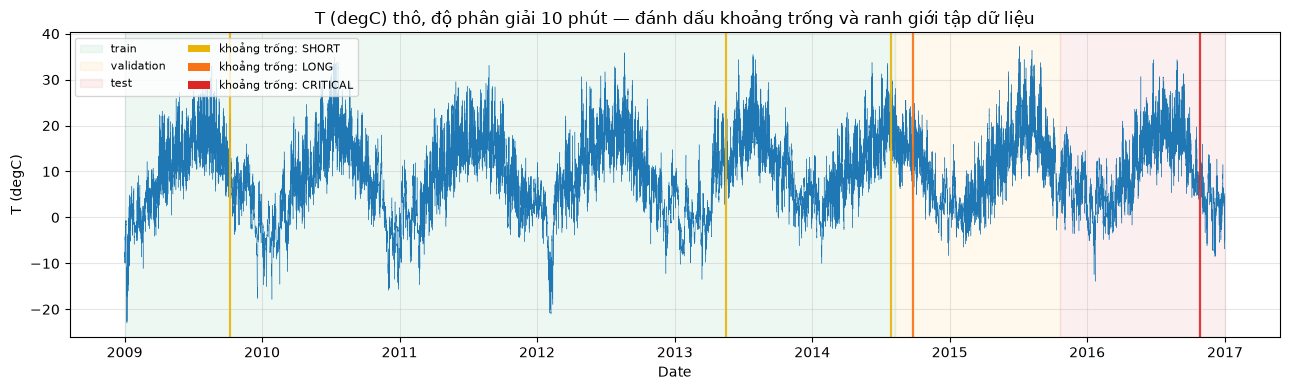

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_raw[TIMESTAMP_COLUMN], df_raw[TARGET_COLUMN], linewidth=0.3, color="#1f77b4")

split_colors = {"train": "#16a34a", "validation": "#f59e0b", "test": "#dc2626"}
for boundary in report["gap_summary"]["split_boundaries"]:
    ax.axvspan(
        pd.Timestamp(boundary["start"]),
        pd.Timestamp(boundary["end"]),
        color=split_colors[boundary["split"]],
        alpha=0.07,
        label=boundary["split"],
    )

severity_colors = {"SHORT": "#eab308", "LONG": "#f97316", "CRITICAL": "#dc2626"}
gap_df = pd.DataFrame(report["gap_summary"]["gaps"])
for _, gap_row in gap_df.iterrows():
    ax.axvline(pd.Timestamp(gap_row["start"]), color=severity_colors[gap_row["severity"]], linewidth=1.6, alpha=0.9)

split_handles, split_labels = ax.get_legend_handles_labels()
by_label = dict(zip(split_labels, split_handles))
gap_handles = [Patch(facecolor=c, label=f"khoảng trống: {s}") for s, c in severity_colors.items()]
ax.legend(
    list(by_label.values()) + gap_handles,
    list(by_label.keys()) + [h.get_label() for h in gap_handles],
    loc="upper left",
    fontsize=8,
    ncol=2,
)
ax.set_title("T (degC) thô, độ phân giải 10 phút — đánh dấu khoảng trống và ranh giới tập dữ liệu")
ax.set_xlabel("Thời gian")
ax.set_ylabel("T (degC)")
fig.tight_layout()
plt.show()

**Phát hiện.** Bản thân chuỗi nhiệt độ trông liên tục và
đều đặn theo mùa trong suốt toàn bộ khoảng thời gian; các khoảng trống tìm thấy ở §4 là ngắn
so với 8 năm dữ liệu nhưng phân bố không đều — lớp phủ tập dữ liệu
cho thấy mỗi khoảng trống rơi vào tập dữ liệu nào (huấn luyện/xác thực/kiểm thử).

**Ảnh hưởng.** Một khoảng trống rơi vào bên trong một cửa sổ ứng viên 168h đầu vào + 72h dự báo
sẽ khiến mô hình huấn luyện hoặc đánh giá trên một chuỗi bị bịa đặt hoặc
không liên tục nếu bộ sinh cửa sổ không kiểm tra rõ ràng
điều này. Một khoảng trống nằm gần ranh giới tập dữ liệu cũng đáng để kiểm tra kỹ xem
nó có khiến một cửa sổ vắt qua hai tập dữ liệu hay không.

**Quyết định.** `WeatherForecastDataset` (`src/data/dataset.py`) quét mọi
cửa sổ ứng viên và loại bỏ nó nếu bất kỳ hàng nào trong khoảng 168h đầu vào hoặc 72h mục tiêu
là NaN/Inf — đây chính xác là những gì một khoảng trống trở thành sau khi lấy mẫu lại
(§4). Kết hợp với việc xây dựng một đối tượng tập dữ liệu riêng cho mỗi tập dữ liệu từ
các khoảng hàng không chồng lấn, một cửa sổ không bao giờ có thể âm thầm vắt qua một khoảng trống hay
một ranh giới tập dữ liệu.

## 3. Phân tích Dữ liệu Thiếu & Giá trị giá trị mã hóa thiếu

Số lượng/tỷ lệ ô thiếu theo từng cột (`report["missing_summary"]`), sau đó là
các mã giá trị mã hóa thiếu kiểu `-9999` (`report["sentinel_summary"]`, từ
`configs/data.yaml missing.sentinel_values`) — số lượng, tỷ lệ, và *thời điểm*
chúng xuất hiện.

In [5]:
missing_table = pd.DataFrame(report["missing_summary"]["by_column"]).set_index("column")
print(f"Tổng số ô thiếu: {report['missing_summary']['total_missing_cells']:,} "
      f"({report['missing_summary']['missing_rate_overall']:.4%} tổng số ô)")
missing_table

Tổng số ô thiếu: 0 (0.0000% tổng số ô)


,missing_count,missing_rate
column,,
Date Time,0,0.0
p (mbar),0,0.0
T (degC),0,0.0
Tpot (K),0,0.0
Tdew (degC),0,0.0
rh (%),0,0.0
VPmax (mbar),0,0.0
VPact (mbar),0,0.0
VPdef (mbar),0,0.0


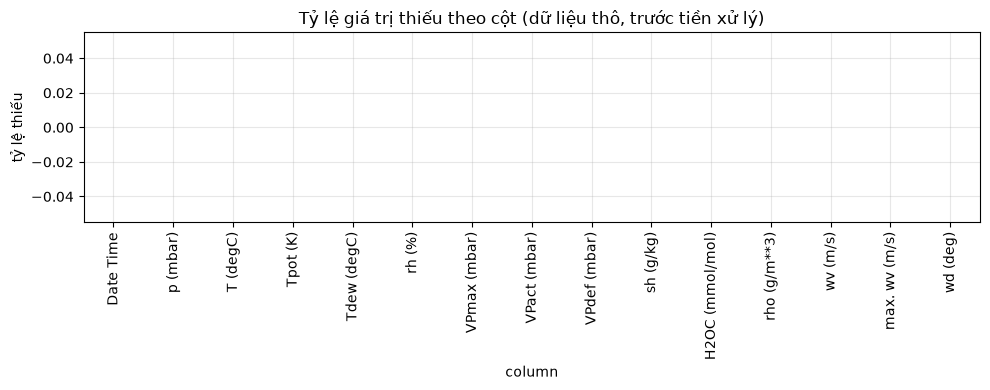

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
missing_table["missing_rate"].sort_values(ascending=False).plot(kind="bar", ax=ax, color="#1f77b4")
ax.set_ylabel("tỷ lệ thiếu")
ax.set_title("Tỷ lệ giá trị thiếu theo cột (dữ liệu thô, trước tiền xử lý)")
fig.tight_layout()
plt.show()

In [7]:
sentinel_summary_rows = []
for column_block in report["sentinel_summary"]["by_column"]:
    if column_block.get("sentinel_count", 0) == 0:
        continue
    positions = column_block["positions"]
    row_indices = [p["row_index"] for p in positions]
    observed_values = sorted(df_raw.loc[row_indices, column_block["column"]].unique().tolist())
    times = pd.to_datetime(
        [p[TIMESTAMP_COLUMN] for p in positions], format=TIMESTAMP_FORMAT
    )
    sentinel_summary_rows.append(
        {
            "feature": column_block["column"],
            "sentinel_value": observed_values,
            "count": column_block["sentinel_count"],
            "rate_pct": round(column_block["sentinel_rate"] * 100, 4),
            "first_time": times.min(),
            "last_time": times.max(),
        }
    )

if sentinel_summary_rows:
    sentinel_table = pd.DataFrame(sentinel_summary_rows).set_index("feature")
else:
    sentinel_table = pd.DataFrame(
        columns=["sentinel_value", "count", "rate_pct", "first_time", "last_time"]
    )
    sentinel_table.index.name = "feature"

print(
    "Các giá trị mã hóa thiếu đã kiểm tra (configs/data.yaml missing.sentinel_values): "
    f"{report['sentinel_summary']['sentinel_values']}"
)
print(
    "Các cột mã hóa thiếu đã kiểm tra (configs/data.yaml missing.sentinel_columns): "
    f"{report['sentinel_summary']['sentinel_columns']}"
)
print(f"Tổng số hàng chứa giá trị mã hóa thiếu: {report['sentinel_summary']['total_sentinel_count']}")
sentinel_table

Các giá trị mã hóa thiếu đã kiểm tra (configs/data.yaml missing.sentinel_values): [-9999, -9999.0]
Các cột mã hóa thiếu đã kiểm tra (configs/data.yaml missing.sentinel_columns): ['wv (m/s)', 'max. wv (m/s)']
Tổng số hàng chứa giá trị mã hóa thiếu: 38


,sentinel_value,count,rate_pct,first_time,last_time
feature,,,,,
wv (m/s),[-9999.0],18,0.0043,2015-07-13 09:10:00,2015-07-13 12:00:00
max. wv (m/s),[-9999.0],20,0.0048,2015-07-13 09:00:00,2015-07-13 12:10:00


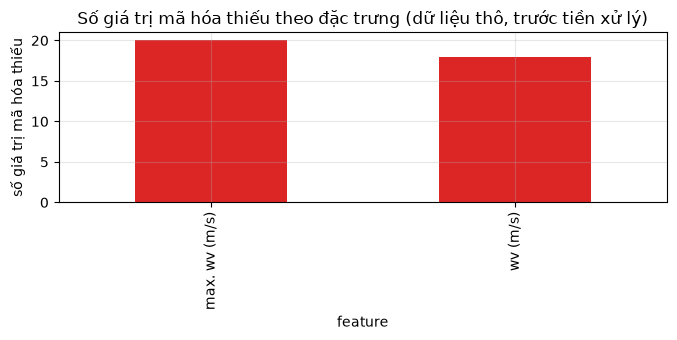

In [8]:
if not sentinel_table.empty:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    sentinel_table["count"].sort_values(ascending=False).plot(kind="bar", color="#dc2626", ax=ax)
    ax.set_ylabel("số giá trị mã hóa thiếu")
    ax.set_xlabel("đặc trưng")
    ax.set_title("Số giá trị mã hóa thiếu theo đặc trưng (dữ liệu thô, trước tiền xử lý)")
    fig.tight_layout()
    plt.show()
else:
    print("Không tìm thấy giá trị mã hóa thiếu trong các cột cấu hình — bỏ qua biểu đồ cột số lượng.")

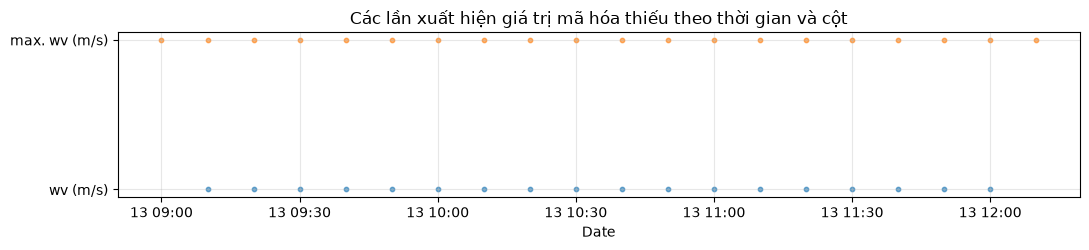

In [9]:
if not sentinel_table.empty:
    fig, ax = plt.subplots(figsize=(11, 2.6))
    for column_block in report["sentinel_summary"]["by_column"]:
        if column_block.get("sentinel_count", 0) == 0:
            continue
        times = pd.to_datetime(
            [p[TIMESTAMP_COLUMN] for p in column_block["positions"]], format=TIMESTAMP_FORMAT
        )
        ax.scatter(times, [column_block["column"]] * len(times), s=10, alpha=0.6)
    ax.set_title("Các lần xuất hiện giá trị mã hóa thiếu theo thời gian và cột")
    ax.set_xlabel("Date")
    fig.tight_layout()
    plt.show()
else:
    print("Không tìm thấy giá trị mã hóa thiếu trong các cột cấu hình — bỏ qua biểu đồ dòng thời gian.")

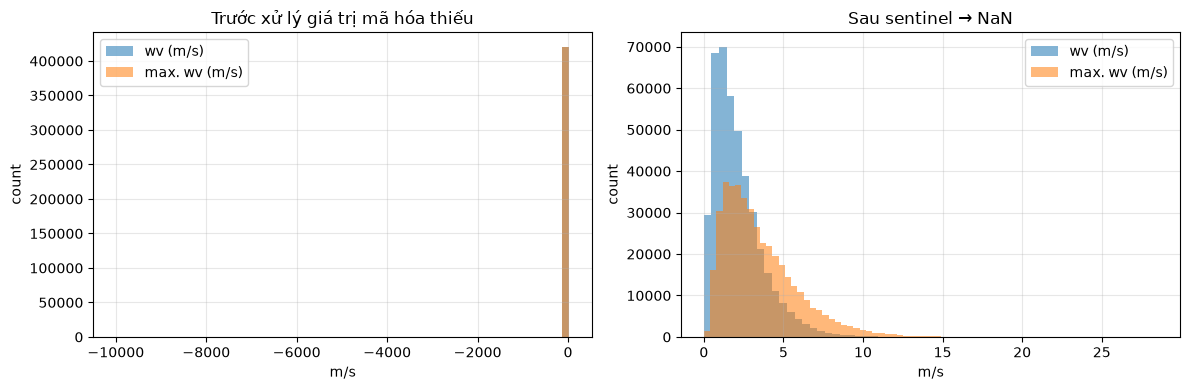

In [10]:
sentinel_clean, _ = pp.handle_sentinels(df_raw)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, frame, title in zip(axes, [df_raw, sentinel_clean], ["Trước xử lý giá trị mã hóa thiếu", "Sau sentinel → NaN"]):
    for column in DATA_CONFIG["missing"]["sentinel_columns"]:
        ax.hist(frame[column].dropna(), bins=60, alpha=0.55, label=column)
    ax.set_title(title); ax.set_xlabel("m/s"); ax.set_ylabel("số lượng"); ax.legend()
fig.tight_layout(); plt.show()

**Phát hiện.** giá trị mã hóa thiếu làm méo mạnh miền phân phối trước xử lý; sau khi đổi thành NaN, phân phối hai cột gió trở về miền quan sát hợp lý.  
**Ảnh hưởng.** Tổng hợp trực tiếp trên `-9999` sẽ tạo thống kê theo giờ sai.  
**Quyết định.** Luôn gọi `handle_sentinels()` trước `resample_hourly()`.

In [11]:
# --- Khẳng định 1: giá trị mã hóa thiếu không được xuất hiện ngoài các cột đã cấu hình ---
sentinel_values_cfg = DATA_CONFIG["missing"]["sentinel_values"]
sentinel_columns_cfg = DATA_CONFIG["missing"]["sentinel_columns"]
other_raw_columns = [
    c for c in df_raw.columns if c != TIMESTAMP_COLUMN and c not in sentinel_columns_cfg
]
unexpected_sentinel_hits = {
    column: int(df_raw[column].isin(sentinel_values_cfg).sum())
    for column in other_raw_columns
    if df_raw[column].isin(sentinel_values_cfg).sum() > 0
}
assert not unexpected_sentinel_hits, (
    "Tìm thấy giá trị mã hóa thiếu ngoài các cột cấu hình: "
    f"{unexpected_sentinel_hits}"
)

# --- Khẳng định 2: mọi mốc có giá trị mã hóa thiếu phải hợp lệ và nằm trong khoảng ngày của file thô ---
report_date_min = pd.Timestamp(report["timestamp"]["date_min"])
report_date_max = pd.Timestamp(report["timestamp"]["date_max"])
for feature, row in sentinel_table.iterrows():
    assert pd.notna(row["first_time"]) and pd.notna(row["last_time"]), (
        f"{feature}: mốc thời gian của giá trị mã hóa thiếu bị thiếu/NaT"
    )
    assert report_date_min <= row["first_time"] <= row["last_time"] <= report_date_max, (
        f"{feature}: khoảng mốc thời gian của giá trị mã hóa thiếu {row['first_time']}..{row['last_time']} "
        f"nằm ngoài khoảng ngày của file thô {report_date_min}..{report_date_max}"
    )

print(
    "ĐẠT: giá trị mã hóa thiếu chỉ xuất hiện trong các cột cấu hình "
    f"{sentinel_columns_cfg}, và mọi mốc thời gian chứa giá trị mã hóa thiếu đều hợp lệ và nằm trong "
    f"[{report_date_min}, {report_date_max}]."
)

ĐẠT: giá trị mã hóa thiếu chỉ xuất hiện trong các cột cấu hình ['wv (m/s)', 'max. wv (m/s)']; mọi mốc tương ứng đều hợp lệ và nằm trong [2009-01-01 00:10:00, 2017-01-01 00:00:00].


**Phát hiện.** Không có ô `NaN` nào trong toàn bộ file CSV thô — bảng tỷ lệ
thiếu ở trên toàn số 0. Nhưng việc quét giá trị mã hóa thiếu lại cho thấy một câu chuyện
khác: bảng tóm tắt giá trị mã hóa thiếu ở trên xác nhận đúng 2 cột bị ảnh hưởng —
`wv (m/s)` (18 lần, giá trị `-9999.0`) và `max. wv (m/s)` (20 lần, giá trị
`-9999.0`), tổng cộng 38/420.551 hàng thô (≈0.009%). Quan trọng hơn số đếm:
cả 38 lần xuất hiện đều **tập trung trong đúng một cửa sổ ~3 giờ 10 phút của
ngày 2015-07-13** (`wv (m/s)`: 09:10 → 12:00; `max. wv (m/s)`: 09:00 → 12:10)
— *tập trung*, không hề *rải rác* trên toàn bộ 8 năm dữ liệu, đúng như bar
biểu đồ và dòng thời gian ở trên thể hiện trực quan. Các giá trị tập trung trong một khoảng thời gian ngắn, phù hợp với giả thuyết
một sự cố hoặc trạng thái không hợp lệ của cảm biến gió. Không có siêu dữ liệu cảm
biến để kết luận chắc chắn nguyên nhân.

**Ảnh hưởng.** Một kiểm tra cấu trúc "có phải `NaN` không" sẽ bỏ sót hoàn
toàn điều này — `-9999.0` là một số thực hữu hạn hoàn toàn hợp lệ, nên nó sẽ
đi thẳng vào giá trị trung bình/lớn nhất theo giờ và âm thầm làm hỏng đúng
các khoảng theo giờ rơi vào cửa sổ 09:00–12:10 ngày 2015-07-13 (giá trị trung
bình tốc độ gió hàng nghìn m/s không phải là lỗi tinh vi để phát hiện sau
này). Lưu ý: sự kiện này *không* xuất hiện trong bảng khoảng trống ở §4, vì §4 chỉ
phát hiện mốc thời gian bị thiếu hoàn toàn — ở đây mốc thời gian vẫn tồn tại, chỉ có
giá trị đo là giá trị mã hóa thiếu. Vì sự kiện kéo dài xấp xỉ `forward_fill_max_hours=3`
(`configs/data.yaml`), sau khi lấy mẫu lại về giờ, các bin bị ảnh hưởng sẽ được
xử lý bởi đúng cơ chế điền xuôi/để-NaN mà `impute_missing()` áp dụng cho
mọi khoảng trống khác — không phải một nhánh xử lý riêng cho giá trị mã hóa thiếu.

**Quyết định.** `src/data/preprocessing.py` (`handle_sentinels`) thay thế
mọi giá trị giá trị mã hóa thiếu đã cấu hình (đọc từ `configs/data.yaml
missing.sentinel_values`/`sentinel_columns`, không viết cứng ở notebook này
hay trong mô-đun) bằng `NaN` *trước khi* lấy mẫu lại, để một giá trị giá trị mã hóa thiếu
chắc chắn được coi là một giá trị thiếu thực sự — tuân theo cùng chính sách
điền xuôi/khoảng trống dài như bất kỳ khoảng trống nào khác (§4), không
bao giờ được nội suy hay điền ngược. Hai khẳng định kiểm tra ở trên xác nhận thêm:
(1) không có giá trị giá trị mã hóa thiếu nào rò rỉ ra ngoài các cột đã khai báo trong
policy, và (2) mọi mốc thời gian giá trị mã hóa thiếu ghi nhận đều nằm trong đúng phạm vi
ngày của file thô — nên bảng/biểu đồ trên là bằng chứng đáng tin cậy, không
phải do lỗi tính toán.

## 4. Phân tích Khoảng trống (Khoảng trống)

Bảng khoảng trống đã sẵn có `start | end | missing_hours | severity |
split` (`report["gap_summary"]`) — các ngưỡng mức độ nghiêm trọng
(`short_gap_threshold_hours`, `long_gap_threshold_hours`) lấy từ
`configs/data.yaml`, không phải giá trị viết cứng ở đây.

In [12]:
print(f"short_gap_threshold_hours={report['gap_summary']['short_gap_threshold_hours']}  "
      f"long_gap_threshold_hours={report['gap_summary']['long_gap_threshold_hours']}  "
      f"(SHORT <= short; LONG <= long; CRITICAL > long)")
gap_table = pd.DataFrame(report["gap_summary"]["gaps"])
gap_table

short_gap_threshold_hours=3  long_gap_threshold_hours=24  (SHORT <= short; LONG <= long; CRITICAL > long)


,start,end,missing_hours,severity,split
0,2009-10-08T09:40:00,2009-10-08T10:10:00,0.5000,SHORT,train
1,2013-05-16T08:50:00,2013-05-16T09:10:00,0.3333,SHORT,train
2,2014-07-30T08:00:00,2014-07-30T08:20:00,0.3333,SHORT,train
3,2014-09-24T17:00:00,2014-09-25T09:00:00,16.0000,LONG,validation
4,2016-10-25T10:30:00,2016-10-28T12:50:00,74.3333,CRITICAL,test


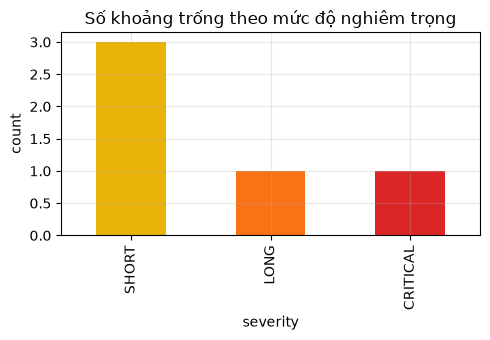

In [13]:
fig, ax = plt.subplots(figsize=(5, 3.5))
severity_order = ["SHORT", "LONG", "CRITICAL"]
severity_counts = gap_table["severity"].value_counts().reindex(severity_order).fillna(0).astype(int)
severity_counts.plot(kind="bar", color=["#eab308", "#f97316", "#dc2626"], ax=ax)
ax.set_title("Số khoảng trống theo mức độ nghiêm trọng")
ax.set_ylabel("số lượng")
fig.tight_layout()
plt.show()

In [14]:
affected_window = (
    gap_table.groupby(["split", "severity"])["missing_hours"]
    .agg(n_gaps="count", total_missing_hours="sum")
    .round(2)
)
affected_window

,,n_gaps,total_missing_hours
split,severity,,
test,CRITICAL,1,74.33
train,SHORT,3,1.17
validation,LONG,1,16.00


In [15]:
input_length = DATA_CONFIG["window"]["input_length_hours"]
horizon = DATA_CONFIG["window"]["horizon_hours"]
clean_for_gaps, _ = pp.clean_timestamps(df_raw)
clean_for_gaps, _ = pp.handle_sentinels(clean_for_gaps)
hourly_for_gaps = pp.resample_hourly(clean_for_gaps)
hourly_for_gaps = pp.add_missing_indicators(pp.add_time_features(hourly_for_gaps))
parts = pp.temporal_split(hourly_for_gaps)[:3]
split_frames = dict(zip(["train", "validation", "test"], parts))
impact_rows = []
for gap_id, gap in gap_table.reset_index(drop=True).iterrows():
    frame = split_frames[gap["split"]]
    starts = np.arange(max(0, len(frame) - input_length - horizon + 1))
    ts = frame[TIMESTAMP_COLUMN].to_numpy()
    gap_start, gap_end = np.datetime64(gap["start"]), np.datetime64(gap["end"])
    input_hit = np.array([((ts[s:s+input_length] > gap_start) & (ts[s:s+input_length] < gap_end)).any() for s in starts])
    target_hit = np.array([((ts[s+input_length:s+input_length+horizon] > gap_start) & (ts[s+input_length:s+input_length+horizon] < gap_end)).any() for s in starts])
    impact_rows.append({"gap": gap_id, "split": gap["split"], "candidate_windows_affected": int((input_hit | target_hit).sum()), "input_only_affected": int((input_hit & ~target_hit).sum()), "target_only_affected": int((~input_hit & target_hit).sum()), "input_and_target_affected": int((input_hit & target_hit).sum())})
gap_window_impact = pd.DataFrame(impact_rows)
gap_window_impact

,gap,split,candidate_windows_affected,input_only_affected,target_only_affected,input_and_target_affected
0,0,train,240,168,72,0
1,1,train,240,168,72,0
2,2,train,0,0,0,0
3,3,validation,254,168,72,14
4,4,test,313,168,72,73


**Phát hiện.** Bảng bổ sung quy đổi từng khoảng trống thành số cửa sổ ứng viên chịu ảnh hưởng theo tập dữ liệu và theo vị trí đầu vào/mục tiêu.  
**Ảnh hưởng.** Một số giờ thiếu có thể loại nhiều cửa sổ 168h/72h liên tiếp.  
**Quyết định.** Giữ nguyên chính sách khoảng trống; dùng bảng này để định lượng tác động lên số lượng mẫu sẵn có.

**Phát hiện.** Mọi khoảng trống tìm thấy trong file thô đều rơi vào một
nhóm mức độ nghiêm trọng riêng biệt, và bảng trên cho thấy mỗi khoảng trống rơi vào tập dữ liệu nào
— kể cả việc khoảng trống nghiêm trọng nhất (CRITICAL) duy nhất nằm trong
huấn luyện, xác thực, hay kiểm thử.

**Ảnh hưởng.** Một khoảng trống SHORT chỉ là một lỗ hổng nhỏ, có thể lấp được; một khoảng trống LONG hoặc CRITICAL
đủ dài để việc bịa ra một giá trị xuyên qua nó (nội suy, fill trên phạm vi
dài) sẽ tạo ra một xu hướng mà cảm biến chưa từng ghi nhận —
đặc biệt rủi ro nếu khoảng trống đó nằm trong tập dữ liệu dùng để báo cáo
hiệu năng cuối cùng của mô hình.

**Quyết định.** Theo `configs/data.yaml missing.*`: các khoảng trống SHORT được
điền xuôi nhân quả (chỉ với đặc trưng đầu vào, giới hạn tối đa
`forward_fill_max_hours`); các khoảng trống LONG và CRITICAL được để nguyên là `NaN`, và
`WeatherForecastDataset` biến chúng thành "loại bỏ cửa sổ này" thay vì
một đầu vào hay mục tiêu bịa đặt (§2). Cột mục tiêu không bao giờ được bù thiếu ở
bất kỳ mức độ nghiêm trọng khoảng trống nào.

## 5. Phân tích Tính mùa vụ (Tính mùa vụ)

Cấu trúc theo ngày (giờ trong ngày) và theo năm (tháng) trong mục tiêu thô,
tính trên toàn bộ chuỗi 10 phút (tổng hợp để vẽ biểu đồ, không lấy mẫu con).

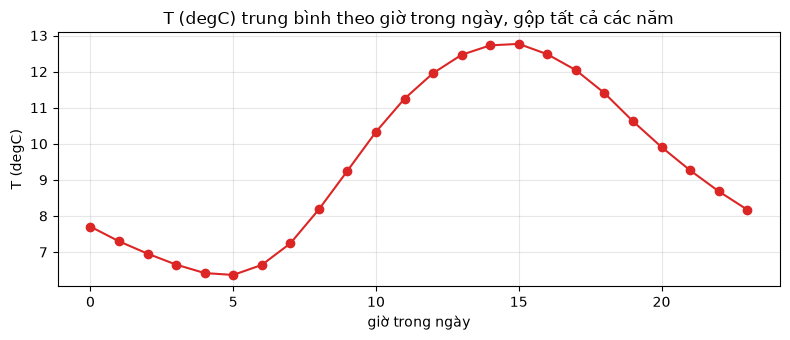

In [16]:
hour_of_day = df_raw[TIMESTAMP_COLUMN].dt.hour
hourly_pattern = df_raw.groupby(hour_of_day)[TARGET_COLUMN].mean()

fig, ax = plt.subplots(figsize=(8, 3.5))
hourly_pattern.plot(ax=ax, marker="o", color="#dc2626")
ax.set_title("T (degC) trung bình theo giờ trong ngày, gộp tất cả các năm")
ax.set_xlabel("giờ trong ngày")
ax.set_ylabel("T (degC)")
fig.tight_layout()
plt.show()

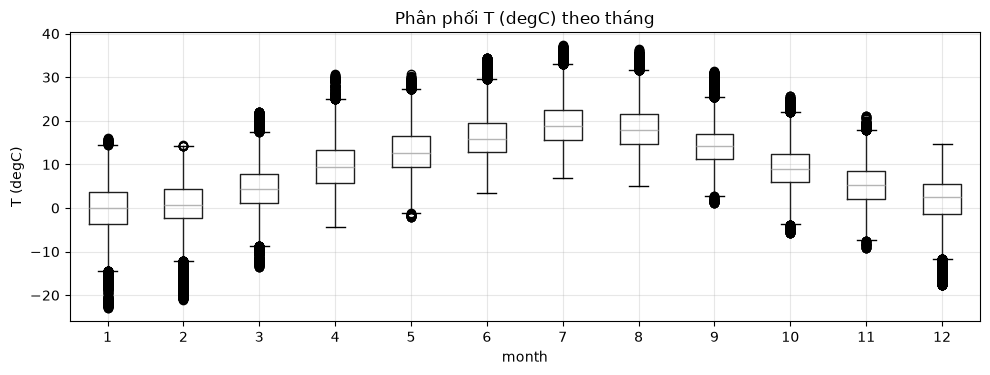

In [17]:
month = df_raw[TIMESTAMP_COLUMN].dt.month
fig, ax = plt.subplots(figsize=(10, 4))
df_raw.assign(_month=month).boxplot(column=TARGET_COLUMN, by="_month", ax=ax)
ax.set_title("Phân phối T (degC) theo tháng")
plt.suptitle("")
ax.set_xlabel("month")
ax.set_ylabel("T (degC)")
fig.tight_layout()
plt.show()

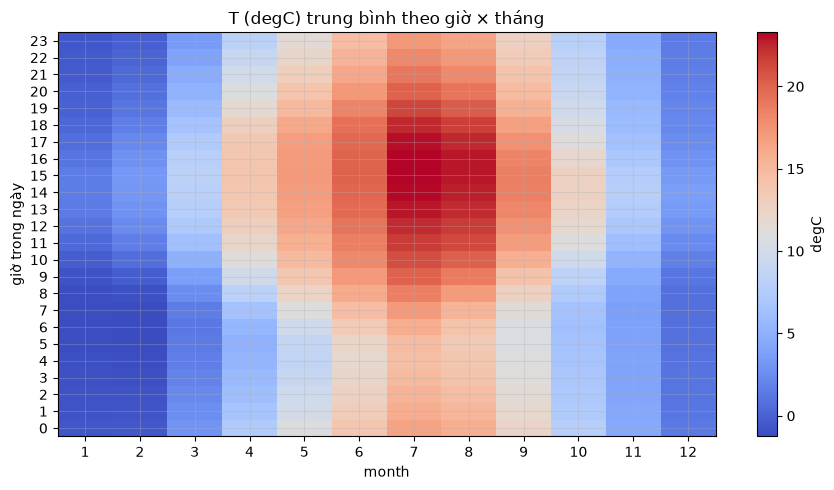

In [18]:
pivot = df_raw.assign(_hour=hour_of_day, _month=month).pivot_table(
    index="_hour", columns="_month", values=TARGET_COLUMN, aggfunc="mean"
)
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap="coolwarm")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("month")
ax.set_ylabel("giờ trong ngày")
ax.set_title("T (degC) trung bình theo giờ × tháng")
fig.colorbar(im, ax=ax, label="degC")
fig.tight_layout()
plt.show()

**Phát hiện.** Nhiệt độ có một chu kỳ ngày rõ rệt (thấp gần lúc rạng sáng, đỉnh
vào giữa buổi chiều) và một chu kỳ năm rõ rệt (lạnh nhất vào tháng 1/2, ấm nhất vào tháng 7/8);
biểu đồ nhiệt tháng x giờ cho thấy hai chu kỳ này không độc lập — biên độ
dao động trong ngày tự nó thay đổi theo mùa.

**Ảnh hưởng.** Một đặc trưng `hour` hoặc `month` dạng số nguyên thô ngụ ý một sự
gián đoạn giả mà mô hình phải học xung quanh (giờ 23 và giờ 0 liền kề nhau
về thời gian nhưng lại cách xa nhau nhất khi ở dạng số nguyên thô), và một cách mã hóa
tuyến tính/phân loại không thể biểu diễn hai chu kỳ chồng lấn được thể hiện ở đây.

**Quyết định.** `src/data/preprocessing.py` (`add_time_features`) mã hóa
`hour` và `day_of_year` thành cặp sin/cos (`hour_sin`/`hour_cos`,
`dayofyear_sin`/`dayofyear_cos`) để các thời điểm liền kề luôn gần nhau trong
không gian đặc trưng ở cả quy mô ngày lẫn năm, thay vì dùng số nguyên thô
hoặc mã hóa độc nóng tháng.

## 6. Phân tích Tương quan (Tương quan)

Ma trận tương quan Pearson giữa các cột số thô (bao gồm cả `T (degC)`), và
ACF/PACF của chuỗi `T (degC)` thô để định lượng mức độ tự tương quan theo
thời gian — cả hai đều tính trực tiếp trên file thô, không qua lấy mẫu lại.

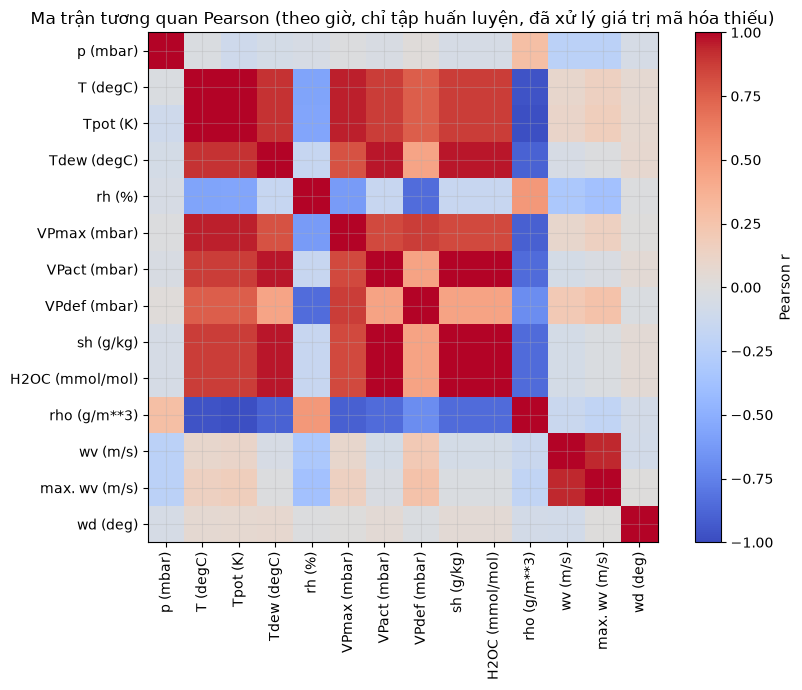

T (degC)           1.000000
Tpot (K)           0.997027
VPmax (mbar)       0.949918
Tdew (degC)        0.901921
VPact (mbar)       0.870735
H2OC (mmol/mol)    0.870106
sh (g/kg)          0.869645
VPdef (mbar)       0.757203
max. wv (m/s)      0.146973
wv (m/s)           0.087939
wd (deg)           0.059918
p (mbar)          -0.028421
rh (%)            -0.563163
rho (g/m**3)      -0.965100
Name: T (degC), dtype: float64

In [19]:
clean_corr, _ = pp.clean_timestamps(df_raw)
clean_corr, _ = pp.handle_sentinels(clean_corr)
hourly_corr = pp.resample_hourly(clean_corr)
train_corr = pp.temporal_split(hourly_corr)[0]
numeric_columns = [col for col in train_corr.columns if col != TIMESTAMP_COLUMN]
corr_matrix = train_corr[numeric_columns].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(numeric_columns))); ax.set_xticklabels(numeric_columns, rotation=90)
ax.set_yticks(range(len(numeric_columns))); ax.set_yticklabels(numeric_columns)
ax.set_title("Ma trận tương quan Pearson (theo giờ, chỉ tập huấn luyện, đã xử lý giá trị mã hóa thiếu)")
fig.colorbar(im, ax=ax, label="Pearson r"); fig.tight_layout(); plt.show()
corr_matrix[TARGET_COLUMN].sort_values(ascending=False)

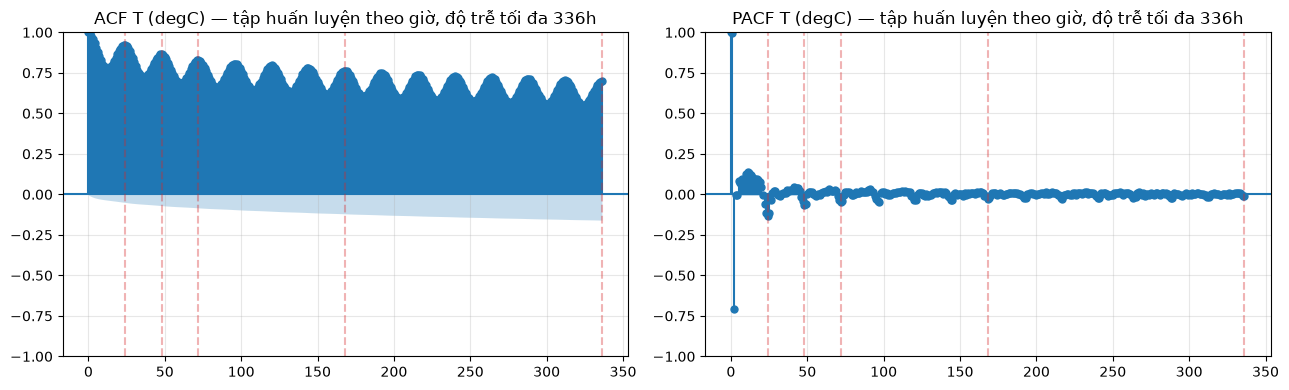

,acf
lag_hours,
24,0.921206
48,0.865496
72,0.828431
168,0.764397
336,0.697495


In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

target_series = train_corr[TARGET_COLUMN].dropna()
max_lag = 336
marks = [24, 48, 72, 168, 336]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(target_series, lags=max_lag, ax=axes[0])
plot_pacf(target_series, lags=max_lag, method="ywm", ax=axes[1])
for ax in axes:
    for lag in marks: ax.axvline(lag, color="tab:red", alpha=.35, linestyle="--")
axes[0].set_title(f"ACF {TARGET_COLUMN} — tập huấn luyện theo giờ, độ trễ tối đa {max_lag}h")
axes[1].set_title(f"PACF {TARGET_COLUMN} — tập huấn luyện theo giờ, độ trễ tối đa {max_lag}h")
fig.tight_layout(); plt.show()
acf_values = acf(target_series, nlags=max_lag, fft=True)
pd.DataFrame({"lag_hours": marks, "acf": [acf_values[x] for x in marks]}).set_index("lag_hours")

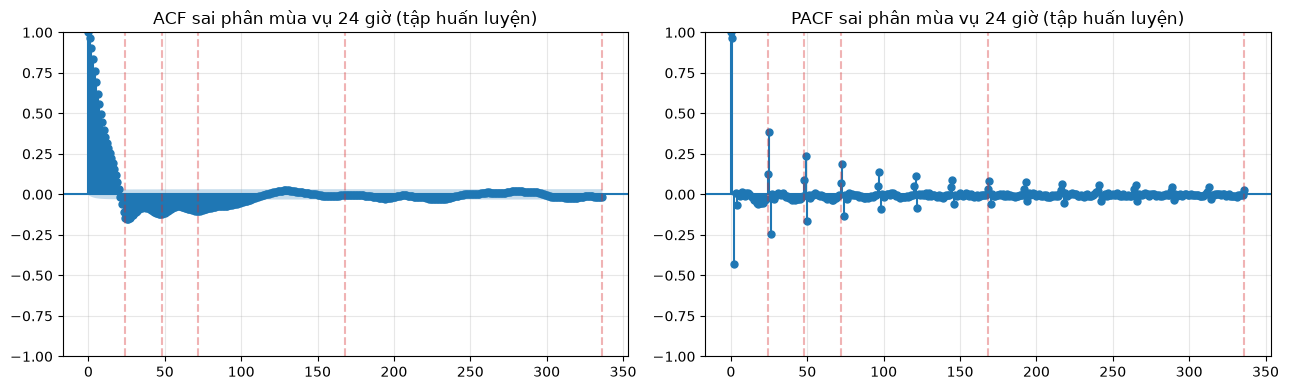

In [21]:
seasonal_diff = target_series.diff(24).dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(seasonal_diff, lags=max_lag, ax=axes[0]); plot_pacf(seasonal_diff, lags=max_lag, method="ywm", ax=axes[1])
for ax in axes:
    for lag in marks: ax.axvline(lag, color="tab:red", alpha=.35, linestyle="--")
axes[0].set_title("ACF sai phân mùa vụ 24 giờ (tập huấn luyện)"); axes[1].set_title("PACF sai phân mùa vụ 24 giờ (tập huấn luyện)")
fig.tight_layout(); plt.show()

**Lưu ý diễn giải.** tương quan Pearson không chứng minh quan hệ nhân quả. Tương quan thấp của đặc trưng gió chỉ được diễn giải sau xử lý giá trị mã hóa thiếu, và không đặc trưng nào bị loại chỉ dựa trên tương quan. ACF/PACF hỗ trợ việc sử dụng 168 giờ làm độ dài nhìn lại cơ sở; lựa chọn tối ưu cần được kiểm chứng bằng kiểm định trên tập xác thực/thử nghiệm loại trừ.

**Phát hiện.** `T (degC)` tương quan rất mạnh với các đại lượng nhiệt-động
lực học được suy ra trực tiếp từ nhiệt độ: `Tpot (K)` (r ≈ 0.997),
`rho (g/m**3)` (r ≈ -0.963), `VPmax (mbar)` (r ≈ 0.951), `Tdew (degC)` (r ≈ 0.896),
và `VPact (mbar)`/`H2OC (mmol/mol)`/`sh (g/kg)` (r ≈ 0.87 mỗi cột); ngược lại các
cột gió (`wv (m/s)`, `max. wv (m/s)`, `wd (deg)`) và áp suất gần như không tương
quan tuyến tính với nhiệt độ (|r| < 0.05). ACF của chuỗi nhiệt độ thô phân rã
rất chậm — vẫn còn 0.92 ở lag 144 (24h) và 0.86 ở lag 288 (48h) — cho thấy tín
hiệu trơn, có cấu trúc dài hạn chứ không phải nhiễu; PACF có đúng một đỉnh lớn
ở lag 1 (≈ 1.0), giảm mạnh xuống âm ở lag 2 rồi gần như bằng 0 từ lag 3 trở đi.

**Ảnh hưởng.** Các cột tương quan cao (Tpot, VPmax, VPact, VPdef, sh, H2OC, rho)
đều được suy ra toán học từ chính T/p/rh — đưa tất cả vào mô hình tạo ra dư
thừa thông tin (đa cộng tuyến) mà một mô hình tuyến tính sẽ khó xử lý, nhưng
một bộ mã hóa seq2seq/attention có thể tận dụng vì các cột này không hoàn toàn
trùng nhau (mỗi cột mang thêm một chút thông tin từ áp suất hơi nước, độ ẩm...).
ACF/PACF phân rã chậm xác nhận rằng lịch sử 168 giờ mang đủ tín hiệu tự tương
quan (cả ngắn hạn lẫn theo chu kỳ ngày) để mô hình khai thác, đồng thời cho thấy
một đường cơ sở duy trì giá trị cuối (dự báo bằng giá trị quan sát cuối cùng) sẽ là một mốc so
sánh rất khó vượt qua vì T(t) gần như luôn rất giống T(t-1).

**Quyết định.** Notebook này không loại bỏ bất kỳ cột nào (việc chọn/loại đặc
trưng thuộc `src/data/preprocessing.py`, ngoài phạm vi ở đây — xem phần "Ngoài
phạm vi" ở đầu notebook); phát hiện tương quan chỉ củng cố lý do giữ nguyên
toàn bộ 14 cột thô làm đầu vào thay vì loại bớt cột "dư thừa" một cách thủ công,
và phát hiện ACF/PACF cung cấp cơ sở định lượng cho việc chọn cửa sổ đầu vào 168
giờ (`configs/data.yaml window.input_length_hours`) cũng như cho việc dùng đường cơ sở
persistence khi đánh giá mô hình sau này.

## Tóm tắt

- Dữ liệu thô Jena Climate 10 phút (xem §1 để biết số hàng/cột/khoảng ngày
  chính xác) sạch về lược đồ nhưng không theo đúng thứ tự thời gian và chứa
  mốc thời gian trùng lặp → sắp xếp + loại trùng là bước tiền xử lý bắt buộc đầu tiên.
- Không có ô `NaN` nào, nhưng có một số lượng nhỏ mã giá trị mã hóa thiếu `-9999` trong các
  cột gió → phải được ánh xạ thành `NaN` trước bất kỳ bước tổng hợp nào, không bao giờ
  để nguyên như một con số theo nghĩa đen.
- Một vài khoảng trống thời gian trải từ mức SHORT đến CRITICAL, phân bố không đều
  trên các vùng huấn luyện/xác thực/kiểm thử trong tương lai → khoảng trống ngắn
  được điền xuôi, khoảng trống dài/nghiêm trọng đánh dấu một cửa sổ trượt là không hợp lệ
  thay vì bị bịa đặt.
- Tính mùa vụ theo ngày + theo năm rất rõ rệt, với hai chu kỳ tương tác lẫn nhau →
  dùng đặc trưng thời gian dạng chu kỳ (sin/cos), không dùng số nguyên thô giờ/tháng.
- `T (degC)` tương quan mạnh với các đại lượng được suy ra nhiệt-động lực học từ chính nó (Tpot, VPmax, Tdew, VPact/H2OC/sh, rho) và gần như không tương quan với gió/áp suất; ACF/PACF phân rã chậm kèm một đỉnh PACF nổi bật duy nhất ở lag 1 → 168h lịch sử mang tín hiệu thực sự, và cả 14 cột thô đều được giữ lại làm đầu vào ứng viên cho mô hình thay vì bị loại bớt thủ công.
- Mọi quyết định ở trên đều đã được triển khai trong `src/data/preprocessing.py`
  và `src/data/dataset.py`; notebook này là bằng chứng cho *lý do tại sao*,
  không phải nơi để quyết định bất cứ điều gì một cách tùy tiện.

## Cổng Chất lượng Dữ liệu — Phụ lục Kỹ thuật

In [22]:
blocking_checks = {"schema_status", "timestamp_parse_status"}
gate_rows = []
for check, status in report["quality_status"].items():
    if status == "PASS": gate = "PASS"
    elif check in blocking_checks and status == "FAIL": gate = "ERROR/BLOCKED"
    elif status in {"FAIL", "REVIEW", "REVIEW_REQUIRED"}: gate = "REQUIRES_CLEANING"
    else: gate = "WARNING"
    gate_rows.append({"validator_check": check, "validator_status": status, "gate": gate})
quality_gate = pd.DataFrame(gate_rows)
quality_gate

,validator_check,validator_status,gate
0,schema_status,PASS,PASS
1,timestamp_parse_status,PASS,PASS
2,monotonic_status,FAIL,REQUIRES_CLEANING
3,duplicate_status,REVIEW,REQUIRES_CLEANING
4,missing_status,PASS,PASS
5,sentinel_status,REVIEW,REQUIRES_CLEANING
6,gap_status,REVIEW,REQUIRES_CLEANING
7,overall_status,FAIL,REQUIRES_CLEANING


`ERROR/BLOCKED` ngăn quy trình vì hợp đồng cấu trúc không thể bảo đảm. `REQUIRES_CLEANING` cho biết dữ liệu thô chưa sẵn sàng dùng trực tiếp nhưng các lỗi đã có bước xử lý rõ ràng trong quy trình (sort/deduplicate, giá trị mã hóa thiếu→NaN, lấy mẫu lại và cửa sổ rejection), nên preprocessing vẫn được phép chạy. `CẢNH BÁO` cần xem xét nhưng không tự động chặn; `PASS` không phát hiện vấn đề.